In [ ]:
!pip install imbalanced-learn xgboost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/creditcard.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (204081, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204081 entries, 0 to 204080
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    204081 non-null  float64
 1   V1      204081 non-null  float64
 2   V2      204081 non-null  float64
 3   V3      204081 non-null  float64
 4   V4      204081 non-null  float64
 5   V5      204081 non-null  float64
 6   V6      204081 non-null  float64
 7   V7      204081 non-null  float64
 8   V8      204081 non-null  float64
 9   V9      204081 non-null  float64
 10  V10     204081 non-null  float64
 11  V11     204081 non-null  float64
 12  V12     204080 non-null  float64
 13  V13     204080 non-null  float64
 14  V14     204080 non-null  float64
 15  V15     204080 non-null  float64
 16  V16     204080 non-null  float64
 17  V17     204080 non-null  float64
 18  V18     204080 non-null  float64
 19  V19     204080 non-null  float64
 20  V20     204080 non-null  float64
 21  V21     20

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,204081.000000,204081.000000,204081.000000,204081.000000,204081.000000,204081.000000,204081.000000,204081.000000,204081.000000,204081.000000,...,204080.000000,204080.000000,204080.000000,204080.000000,204080.000000,204080.000000,204080.000000,204080.000000,204080.000000,204080.000000
mean,71913.738030,-0.095800,0.001358,0.295321,0.070008,-0.101545,0.042992,-0.045438,0.014215,0.008529,...,-0.013382,-0.042940,-0.014381,0.003886,0.057186,0.005605,0.001410,0.001783,89.763740,0.001921
std,35414.633349,1.897871,1.626302,1.455324,1.400715,1.363525,1.313405,1.218620,1.208540,1.133307,...,0.737283,0.694143,0.615026,0.603831,0.494689,0.488144,0.395174,0.317946,248.409518,0.043785
min,0.000000,-56.407510,-72.715728,-33.680984,-5.683171,-42.147898,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-11.710896,0.000000,0.000000
25%,44754.000000,-0.959271,-0.583606,-0.376628,-0.797727,-0.777212,-0.714340,-0.574241,-0.183907,-0.662069,...,-0.226685,-0.536587,-0.168448,-0.343110,-0.246274,-0.331284,-0.067779,-0.042977,5.990000,0.000000
50%,68031.000000,-0.078658,0.079378,0.473483,0.070879,-0.159866,-0.222107,-0.006234,0.041168,-0.072345,...,-0.041363,-0.030597,-0.027993,0.051800,0.098885,-0.061097,0.005494,0.018033,23.000000,0.000000
75%,97824.000000,1.218283,0.783351,1.209828,0.877679,0.479239,0.441539,0.508500,0.336823,0.623956,...,0.153914,0.433122,0.116754,0.422865,0.382981,0.260482,0.089114,0.078091,79.380000,0.000000
max,135102.000000,2.454930,22.057729,9.382558,16.875344,34.801666,22.529298,36.677268,20.007208,15.594995,...,27.202839,10.503090,19.002942,4.022866,7.519589,3.517346,12.152401,33.847808,19656.530000,1.000000


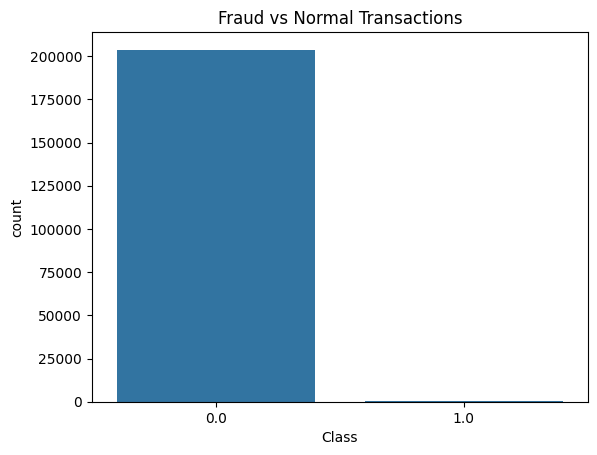

In [ ]:
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

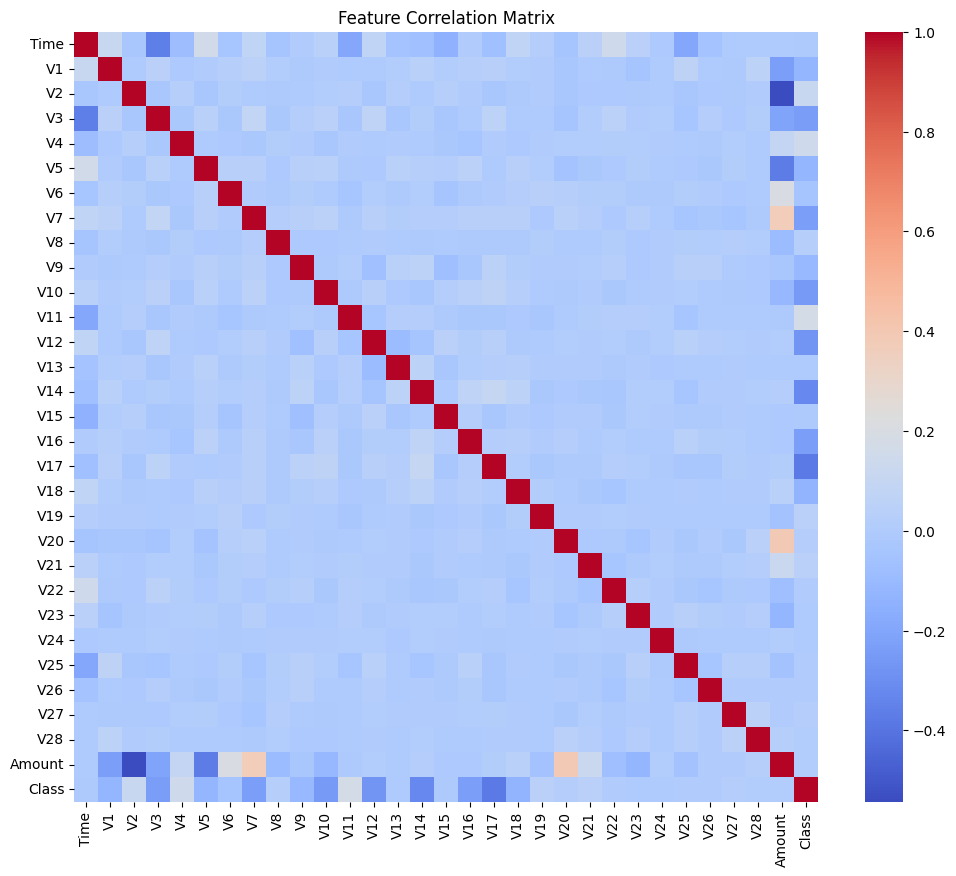

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

In [ ]:
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

In [ ]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

Before SMOTE: Class
0.0    162943
1.0       321
Name: count, dtype: int64
After SMOTE: Class
0.0    162943
1.0    162943
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train_res, y_train_res)

LogisticRegression(max_iter=5000)

In [ ]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_res, y_train_res)

RandomForestClassifier()

In [ ]:
xgb = XGBClassifier()
xgb.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
pred = rf.predict(X_test)

print("Confusion Matrix")
print(confusion_matrix(y_test, pred))

print("\nClassification Report")
print(classification_report(y_test, pred))

Confusion Matrix
[[40737     8]
 [   11    60]]

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     40745
         1.0       0.88      0.85      0.86        71

    accuracy                           1.00     40816
   macro avg       0.94      0.92      0.93     40816
weighted avg       1.00      1.00      1.00     40816



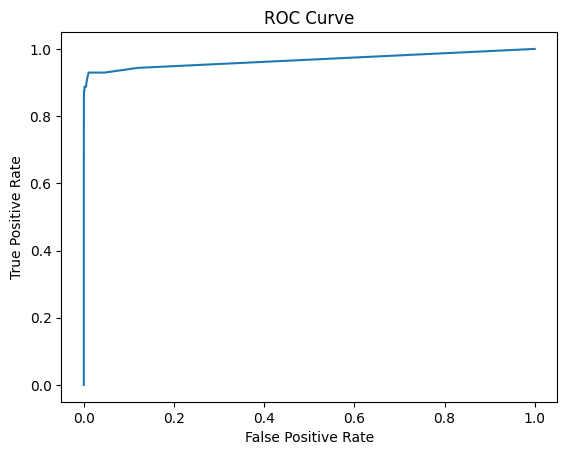

In [ ]:
probs = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, probs)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

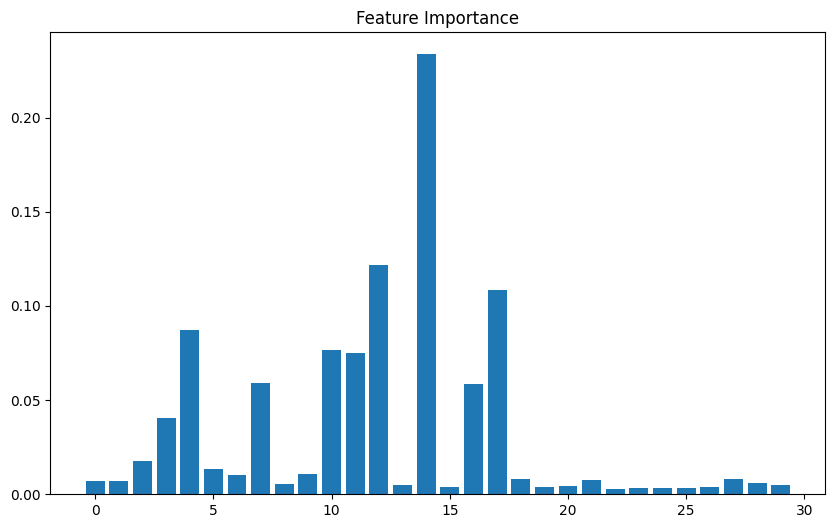

In [ ]:
importances = rf.feature_importances_

plt.figure(figsize=(10,6))
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance")
plt.show()

In [ ]:
import pickle
pickle.dump(rf, open("fraud_model.pkl", "wb"))

In [ ]:
for i in range(1000):
    sample = X_test[i].reshape(1,-1)
    pred = rf.predict(sample)

    if pred[0] == 0:
        print("Transaction", i, ": Normal")
    else:
        print("Transaction", i, ": Fraud")

Transaction 0 : Normal
Transaction 1 : Normal
Transaction 2 : Normal
Transaction 3 : Normal
Transaction 4 : Normal
Transaction 5 : Normal
Transaction 6 : Normal
Transaction 7 : Normal
Transaction 8 : Normal
Transaction 9 : Normal
Transaction 10 : Normal
Transaction 11 : Normal
Transaction 12 : Normal
Transaction 13 : Normal
Transaction 14 : Normal
Transaction 15 : Normal
Transaction 16 : Normal
Transaction 17 : Normal
Transaction 18 : Normal
Transaction 19 : Normal
Transaction 20 : Normal
Transaction 21 : Normal
Transaction 22 : Normal
Transaction 23 : Normal
Transaction 24 : Normal
Transaction 25 : Normal
Transaction 26 : Normal
Transaction 27 : Normal
Transaction 28 : Normal
Transaction 29 : Normal
Transaction 30 : Normal
Transaction 31 : Normal
Transaction 32 : Normal
Transaction 33 : Normal
Transaction 34 : Normal
Transaction 35 : Normal
Transaction 36 : Normal
Transaction 37 : Normal
Transaction 38 : Normal
Transaction 39 : Normal
Transaction 40 : Normal
Transaction 41 : Normal
Tr